# Cleaning ETL8B dataset

This notebook preprocesses the ETL8B dataset to make it ready for machine learning. It cleans and organizes the data, converting the handwritten katakana images into NumPy arrays and storing the corresponding labels. The resulting dataset is saved in .h5 format for efficient loading and use in ML workflows.

**Note:** The file paths used in this notebook are from the Kaggle environment. You may need to adjust them if running the notebook locally.

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/etl8b-uncleaned/ETL8B2C2
/kaggle/input/etl8b-uncleaned/ETL8B2C3
/kaggle/input/etl8b-uncleaned/ETL8B2C1


In [4]:
!pip install bitstring 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.8/314.8 kB 10.4 MB/s eta 0:00:00


In [5]:
import os
import time
import math
import re
import struct
import traceback
import codecs

import bitstring

import numpy as np
import matplotlib.pyplot as plt
# import cv2
import pandas as pd

from PIL import Image
import h5py
import IPython.display as display

## Learning the Bitstream

This section shows how the ETL8B bitstream is structured and how it is converted into character images.

In [26]:
file_list = [
    'ETL8B2C1',
    'ETL8B2C2',
    'ETL8B2C3',
]

In [27]:
filename = file_list[0]
print(filename)
file_stream = bitstring.ConstBitStream(filename="/kaggle/input/etl8b-uncleaned/ETL8B2C1")

ETL8B2C1


### Parsing a Record

The ETL8B dataset stores each sample as a fixed-length binary record. The `readlist()` call extracts the record fields according to the ETL8B specification:

- `int:16` → Sheet number (16-bit integer)
- `uint:16` → JIS character code (16-bit unsigned integer)
- `uint:32` → Character reading identifier (32-bit unsigned integer)
- `bytes:504` → Raw bitmap data


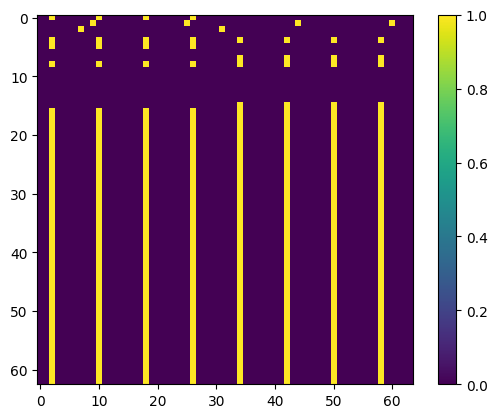

In [ ]:
record = file_stream.readlist('int:16,uint:16,uint:32,bytes:504') # format of the file
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}

width = 64
height = 63

np_img = np.array(Image.frombytes('1', (width, height), record_dict['image_data'], 'raw')).astype(int)
plt.imshow(np_img)
plt.colorbar()

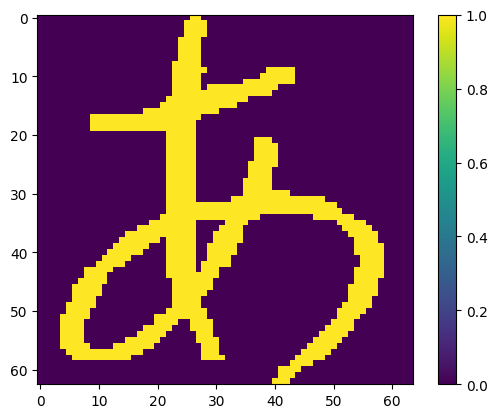

In [47]:
record = file_stream.readlist('int:16,uint:16,uint:32,bytes:504')
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}

width = 64
height = 63

np_img = np.array(Image.frombytes('1', (width, height), record_dict['image_data'], 'raw')).astype(int)
plt.imshow(np_img)
plt.colorbar()
plt.savefig("hiragana.png")

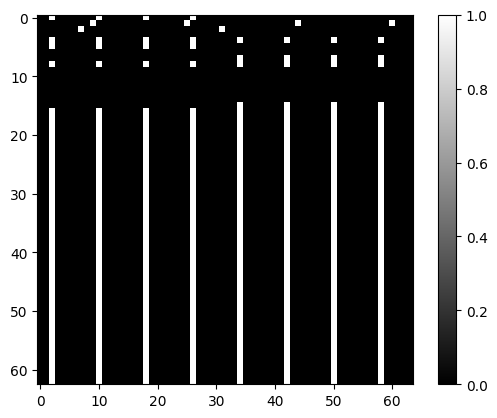

In [30]:
file_stream1 = bitstring.ConstBitStream(filename="/kaggle/input/etl8b-uncleaned/ETL8B2C1")

record = file_stream1.readlist('int:16,uint:16,uint:32,bytes:504')
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}

width = 64
height = 63

np_img = np.array(Image.frombytes('1', (width, height), record_dict['image_data'], 'raw')).astype(int)
plt.imshow(np_img, cmap='gray')
plt.colorbar()

### JIS Encoding
ETL8B2 does not use a standard character encoding scheme, so the character labels must be mapped manually.

In [ ]:
JIS0208 = {
    9249: 'ぁ',
    9250: 'あ',
    9251: 'ぃ',
    9252: 'い',
    9253: 'ぅ',
    9254: 'う',
    9255: 'ぇ',
    9256: 'え',
    9257: 'ぉ',
    9258: 'お',
    9259: 'か',
    9260: 'が',
    9261: 'き',
    9262: 'ぎ',
    9263: 'く',
    9264: 'ぐ',
    9265: 'け',
    9266: 'げ',
    9267: 'こ',
    9268: 'ご',
    9269: 'さ',
    9270: 'ざ',
    9271: 'し',
    9272: 'じ',
    9273: 'す',
    9274: 'ず',
    9275: 'せ',
    9276: 'ぜ',
    9277: 'そ',
    9278: 'ぞ',
    9279: 'た',
    9280: 'だ',
    9281: 'ち',
    9282: 'ぢ',
    9283: 'っ',
    9284: 'つ',
    9285: 'づ',
    9286: 'て',
    9287: 'で',
    9288: 'と',
    9289: 'ど',
    9290: 'な',
    9291: 'に',
    9292: 'ぬ',
    9293: 'ね',
    9294: 'の',
    9295: 'は',
    9296: 'ば',
    9297: 'ぱ',
    9298: 'ひ',
    9299: 'び',
    9300: 'ぴ',
    9301: 'ふ',
    9302: 'ぶ',
    9303: 'ぷ',
    9304: 'へ',
    9305: 'べ',
    9306: 'ぺ',
    9307: 'ほ',
    9308: 'ぼ',
    9309: 'ぽ',
    9310: 'ま',
    9311: 'み',
    9312: 'む',
    9313: 'め',
    9314: 'も',
    9315: 'ゃ',
    9316: 'や',
    9317: 'ゅ',
    9318: 'ゆ',
    9319: 'ょ',
    9320: 'よ',
    9321: 'ら',
    9322: 'り',
    9323: 'る',
    9324: 'れ',
    9325: 'ろ',
    9326: 'ゎ',
    9327: 'わ',
    9328: 'ゐ',
    9329: 'ゑ',
    9330: 'を',
    9331: 'ん',
    9505: 'ァ',
    9506: 'ア',
    9507: 'ィ',
    9508: 'イ',
    9509: 'ゥ',
    9510: 'ウ',
    9511: 'ェ',
    9512: 'エ',
    9513: 'ォ',
    9514: 'オ',
    9515: 'カ',
    9516: 'ガ',
    9517: 'キ',
    9518: 'ギ',
    9519: 'ク',
    9520: 'グ',
    9521: 'ケ',
    9522: 'ゲ',
    9523: 'コ',
    9524: 'ゴ',
    9525: 'サ',
    9526: 'ザ',
    9527: 'シ',
    9528: 'ジ',
    9529: 'ス',
    9530: 'ズ',
    9531: 'セ',
    9532: 'ゼ',
    9533: 'ソ',
    9534: 'ゾ',
    9535: 'タ',
    9536: 'ダ',
    9537: 'チ',
    9538: 'ヂ',
    9539: 'ッ',
    9540: 'ツ',
    9541: 'ヅ',
    9542: 'テ',
    9543: 'デ',
    9544: 'ト',
    9545: 'ド',
    9546: 'ナ',
    9547: 'ニ',
    9548: 'ヌ',
    9549: 'ネ',
    9550: 'ノ',
    9551: 'ハ',
    9552: 'バ',
    9553: 'パ',
    9554: 'ヒ',
    9555: 'ビ',
    9556: 'ピ',
    9557: 'フ',
    9558: 'ブ',
    9559: 'プ',
    9560: 'ヘ',
    9561: 'ベ',
    9562: 'ペ',
    9563: 'ホ',
    9564: 'ボ',
    9565: 'ポ',
    9566: 'マ',
    9567: 'ミ',
    9568: 'ム',
    9569: 'メ',
    9570: 'モ',
    9571: 'ャ',
    9572: 'ヤ',
    9573: 'ュ',
    9574: 'ユ',
    9575: 'ョ',
    9576: 'ヨ',
    9577: 'ラ',
    9578: 'リ',
    9579: 'ル',
    9580: 'レ',
    9581: 'ロ',
    9582: 'ヮ',
    9583: 'ワ',
    9584: 'ヰ',
    9585: 'ヱ',
    9586: 'ヲ',
    9587: 'ン',
    9588: 'ヴ',
    9589: 'ヵ',
    9590: 'ヶ',
}

## Converting Raw Image Data into a Machine Learning Dataset

In [43]:
file_stream1 = bitstring.ConstBitStream(filename="/kaggle/input/etl8b-uncleaned/ETL8B2C1")

record = file_stream1.readlist('int:16,uint:16,uint:32,bytes:504')
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}


hdf5_path = f'{file_list[0]}.h5'

if not os.path.exists(hdf5_path):
    with h5py.File(hdf5_path, 'w') as f:
        f.create_dataset('images', shape=(0, 63, 64), maxshape=(None, 63, 64), dtype='uint8', compression='gzip')
        dt = h5py.special_dtype(vlen=str)
        f.create_dataset('labels', shape=(0,), maxshape=(None,), dtype=dt)

is_kanas = True
with h5py.File(hdf5_path, 'a') as f:
    while is_kanas:
        record = file_stream1.readlist('int:16,uint:16,uint:32,bytes:504')
        record_dict = {
            'sheet_number': record[0], # type: int - Serial Sheet Number
            'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
            'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
            'image_data': record[3], # type: bytes
        }
        if record_dict["JIS_KANJI_CODE"] > 9590:
            is_kanas = False
            break
            
        jis_int = record_dict['JIS_KANJI_CODE']
        kana = JIS0208[jis_int]
        
        img = Image.frombytes('1', (64,63), record_dict['image_data'], 'raw')
        np_img = np.array(img).astype(np.uint8)

        curr_len = f['images'].shape[0]

        f['images'].resize((curr_len+1, 63,64))
        f['labels'].resize((curr_len+1,))
        
        f['images'][curr_len] = np_img
        f['labels'][curr_len] = kana

In [32]:
file_stream2 = bitstring.ConstBitStream(filename="/kaggle/input/etl8b-uncleaned/ETL8B2C2")

record = file_stream2.readlist('int:16,uint:16,uint:32,bytes:504')
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}

hdf5_path2 = f'{file_list[1]}.h5'

if not os.path.exists(hdf5_path2):
    with h5py.File(hdf5_path, 'w') as f:
        f.create_dataset('images', shape=(0, 63, 64), maxshape=(None, 63, 64), dtype='uint8', compression='gzip')
        dt = h5py.special_dtype(vlen=str)
        f.create_dataset('labels', shape=(0,), maxshape=(None,), dtype=dt)

is_kanas = True
with h5py.File(hdf5_path, 'a') as f:
    while is_kanas:
        record = file_stream2.readlist('int:16,uint:16,uint:32,bytes:504')
        record_dict = {
            'sheet_number': record[0], # type: int - Serial Sheet Number
            'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
            'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
            'image_data': record[3], # type: bytes
        }
        if record_dict["JIS_KANJI_CODE"] > 9590:
            is_kanas = False
            break
            
        jis_int = record_dict['JIS_KANJI_CODE']
        kana = JIS0208[jis_int]
        
        img = Image.frombytes('1', (64,63), record_dict['image_data'], 'raw')
        np_img = np.array(img).astype(np.uint8)

        curr_len = f['images'].shape[0]

        f['images'].resize((curr_len+1, 63,64))
        f['labels'].resize((curr_len+1,))
        
        f['images'][curr_len] = np_img
        f['labels'][curr_len] = kana

In [33]:
file_stream3 = bitstring.ConstBitStream(filename="/kaggle/input/etl8b-uncleaned/ETL8B2C3")

record = file_stream3.readlist('int:16,uint:16,uint:32,bytes:504')
record_dict = {
    'sheet_number': record[0], # type: int - Serial Sheet Number
    'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
    'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
    'image_data': record[3], # type: bytes
}

hdf5_path3 = f'{file_list[2]}.h5'

if not os.path.exists(hdf5_path3):
    with h5py.File(hdf5_path, 'w') as f:
        f.create_dataset('images', shape=(0, 63, 64), maxshape=(None, 63, 64), dtype='uint8', compression='gzip')
        dt = h5py.special_dtype(vlen=str)
        f.create_dataset('labels', shape=(0,), maxshape=(None,), dtype=dt)

is_kanas = True
with h5py.File(hdf5_path, 'a') as f:
    while is_kanas:
        record = file_stream3.readlist('int:16,uint:16,uint:32,bytes:504')
        record_dict = {
            'sheet_number': record[0], # type: int - Serial Sheet Number
            'JIS_KANJI_CODE': record[1], # type: binary - JIS Kanji Code (JIS X 0208)
            'JIS_READING': record[2], # type: ASCII - JIS Typical Reading (e.g. 'AI.M')
            'image_data': record[3], # type: bytes
        }
        if record_dict["JIS_KANJI_CODE"] > 9590:
            is_kanas = False
            break
            
        jis_int = record_dict['JIS_KANJI_CODE']
        kana = JIS0208[jis_int]
        
        img = Image.frombytes('1', (64,63), record_dict['image_data'], 'raw')
        np_img = np.array(img).astype(np.uint8)

        curr_len = f['images'].shape[0]

        f['images'].resize((curr_len+1, 63,64))
        f['labels'].resize((curr_len+1,))
        
        f['images'][curr_len] = np_img
        f['labels'][curr_len] = kana

In [46]:
with h5py.File(hdf5_path, 'r') as f:
    imgs = f['images'][:]      # shape: (N, 63, 64)
    labels = f['labels'][:]    # shape: (N,)
    unique_labels = np.unique(labels)
    decoded = [label.decode('utf-8') for label in unique_labels]
    print(decoded)
    print(len(decoded))
  

# with h5py.File(hdf5_path2, 'r') as f:
#     imgs = f['images'][:]      # shape: (N, 63, 64)
#     labels = f['labels'][:]    # shape: (N,)
#     unique_labels = np.unique(labels)
#     decoded = [label.decode('utf-8') for label in unique_labels]
#     print(decoded)


# with h5py.File(hdf5_path3, 'r') as f:
#     imgs = f['images'][:]      # shape: (N, 63, 64)
#     labels = f['labels'][:]    # shape: (N,)
#     unique_labels = np.unique(labels)
#     decoded = [label.decode('utf-8') for label in unique_labels]
#     print(decoded)


['あ', 'い', 'う', 'え', 'お', 'か', 'が', 'き', 'ぎ', 'く', 'ぐ', 'け', 'げ', 'こ', 'ご', 'さ', 'ざ', 'し', 'じ', 'す', 'ず', 'せ', 'ぜ', 'そ', 'ぞ', 'た', 'だ', 'ち', 'ぢ', 'っ', 'つ', 'づ', 'て', 'で', 'と', 'ど', 'な', 'に', 'ぬ', 'ね', 'の', 'は', 'ば', 'ぱ', 'ひ', 'び', 'ぴ', 'ふ', 'ぶ', 'ぷ', 'へ', 'べ', 'ぺ', 'ほ', 'ぼ', 'ぽ', 'ま', 'み', 'む', 'め', 'も', 'ゃ', 'や', 'ゅ', 'ゆ', 'ょ', 'よ', 'ら', 'り', 'る', 'れ', 'ろ', 'わ', 'を', 'ん']
75
